In [544]:
# General Packages
import pandas as pd
import numpy as np
import random as rnd
import os
import re
import itertools
# import multiprocessing

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt
get_ipython().magic('matplotlib inline')
plt.rcParams['figure.figsize'] = (8, 6)
#import scikitplot as skplt
#%load_ext cuml.accel
# Supervised Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, BaggingClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import Perceptron, SGDClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn import feature_selection
import xgboost as xgb # XGBOOST
from xgboost.sklearn import XGBClassifier # XGBOOST
import hyperopt #CatBoost
from catboost import Pool, CatBoostClassifier #CatBoost
import lightgbm as lgb # Light GBM
import statsmodels.api as sm # Logistic Regression with StatModels

# Unsupervised Models
from sklearn.decomposition import PCA

# Evalaluation
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
# Grid
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.feature_selection import RFE
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as st

# Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline

# Esemble Voting
from mlxtend.classifier import EnsembleVoteClassifier
from sklearn import metrics
from sklearn.metrics import classification_report, accuracy_score

# Stacking
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from matplotlib.colors import ListedColormap

# Warnings
import warnings
warnings.filterwarnings(action='ignore')
warnings.filterwarnings(action='ignore', category=DeprecationWarning)
warnings.filterwarnings(action='ignore', category=FutureWarning)

import time
import datetime
import platform
start = time.time()


In [545]:
file_path = r"final_Data.xlsx"
data = pd.read_excel(file_path)
df = pd.DataFrame(data)
df.drop(["Unnamed: 11","Unnamed: 13","Unnamed: 14","Unnamed: 15","Energy Ratio"],axis=1,inplace = True)
columns_to_drop = ['Serial Number', 'Time', 'Waveform Quantity', 'X', 'Y', 'Z','Energy Flux']

# Drop the columns
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')  # `errors='ignore'` prevents errors if a column is missing
df["categories "] = df["categories "].map({"Microseismic": 0, "Blast": 1})
df = df.dropna(subset=["categories "])
df['categories '] = df['categories '].astype(int)


In [546]:
df.columns.str.replace(' ', '') 

Index(['categories', 'AverageWaveVelocity', 'CornerFrequency', 'SeismicEvent',
       'SeismicEnergy', 'PeakSpeed', 'PeakAcceleration',
       'MagnitudeontheRichterScale', 'MomentMagnitude'],
      dtype='object')

In [547]:
df

,categories,Average Wave Velocity,Corner Frequency,Seismic Event,Seismic Energy,Peak Speed,Peak Acceleration,Magnitude on the Richter Scale,Moment Magnitude
0,0,5188.848920,139.548437,3.258031e+08,90.693684,0.004804,11513.127348,0.064868,-0.384470
1,0,4371.604159,179.228437,2.460276e+08,91.360816,0.008625,27418.106361,0.062405,-0.450675
2,0,4431.474664,171.066662,2.255937e+08,67.653525,0.006957,22212.899341,0.002772,-0.485719
3,0,5086.850711,173.267290,3.755549e+08,211.558439,0.012457,39782.646678,0.160840,-0.365789
4,0,4512.221898,177.365142,5.753187e+08,573.474758,0.019600,64969.492512,0.332899,-0.238195
...,...,...,...,...,...,...,...,...,...
6701,0,5250.756222,479.239717,3.220283e+04,0.000017,0.000001,4.919856,-2.983221,-3.056249
6702,0,5323.911702,395.905118,4.190100e+04,0.000018,0.000001,5.889017,-2.975974,-3.005493
6703,0,5426.634481,390.189498,4.555396e+04,0.000017,0.000001,5.593441,-2.930349,-2.963802
6704,0,5137.905252,365.504455,4.812380e+04,0.000017,0.000001,5.735084,-2.939953,-2.955426


### Feature Engineering 

df["Energy_per_Acceleration"] =df["Seismic Energy"]/df["Peak Acceleration"]
df["Velocity_Ratio"] =df["Peak Speed"]/df["Average Wave Velocity"]

### Data Analysis 

#### OUTLIER

In [548]:
def count_outliers_iqr(df):
    outlier_counts = {}

    for col in df.select_dtypes(include='number').columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outlier_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
        outlier_counts[col] = outlier_count

    return pd.Series(outlier_counts, name="Outlier Count")

# Example usage:
outlier_counts = count_outliers_iqr(df)
print(outlier_counts)

categories                          0
Average Wave Velocity               0
Corner Frequency                  224
Seismic Event                     164
Seismic Energy                    739
Peak Speed                        140
Peak Acceleration                 148
Magnitude on the Richter Scale      0
Moment Magnitude                    0
Name: Outlier Count, dtype: int64


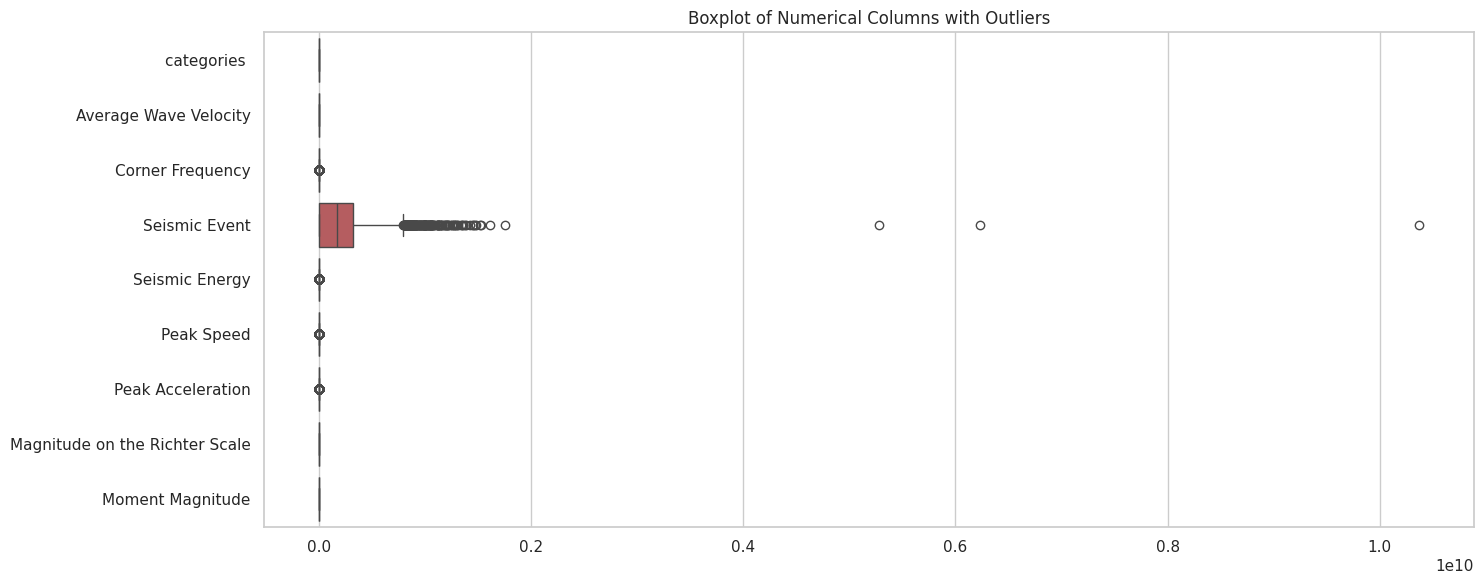

In [549]:

plt.figure(figsize=(15, 6))
sns.boxplot(data=df.select_dtypes(include='number'),orient='h')
plt.title("Boxplot of Numerical Columns with Outliers")
plt.tight_layout()
plt.show()

In [550]:
#### remove outliers

def remove_outliers_iqr(df):
    df_cleaned = df.copy()
    for col in df.select_dtypes(include='number').columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]
    return df_cleaned

df= remove_outliers_iqr(df)

def cap_outliers(df):
    df_capped = df.copy()
    for col in df.select_dtypes(include='number').columns:
        lower = df[col].quantile(0.01)
        upper = df[col].quantile(0.99)
        df_capped[col] = df[col].clip(lower, upper)
    return df_capped

df_cap = cap_outliers(df)

import numpy as np

def replace_outliers_with_median(df):
    df_replaced = df.copy()
    for col in df.select_dtypes(include='number').columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        median = df[col].median()
        df_replaced[col] = np.where(
            (df[col] < lower_bound) | (df[col] > upper_bound),
            median,
            df[col]
        )
    return df_replaced

df_replace = replace_outliers_with_median(df)


In [551]:
df_witout_outliers = df_replace

In [552]:
# Example usage:
outlier_counts = count_outliers_iqr(df_witout_outliers)
print(outlier_counts)

categories                          0
Average Wave Velocity               0
Corner Frequency                    0
Seismic Event                       0
Seismic Energy                    268
Peak Speed                          0
Peak Acceleration                  10
Magnitude on the Richter Scale      0
Moment Magnitude                    0
Name: Outlier Count, dtype: int64


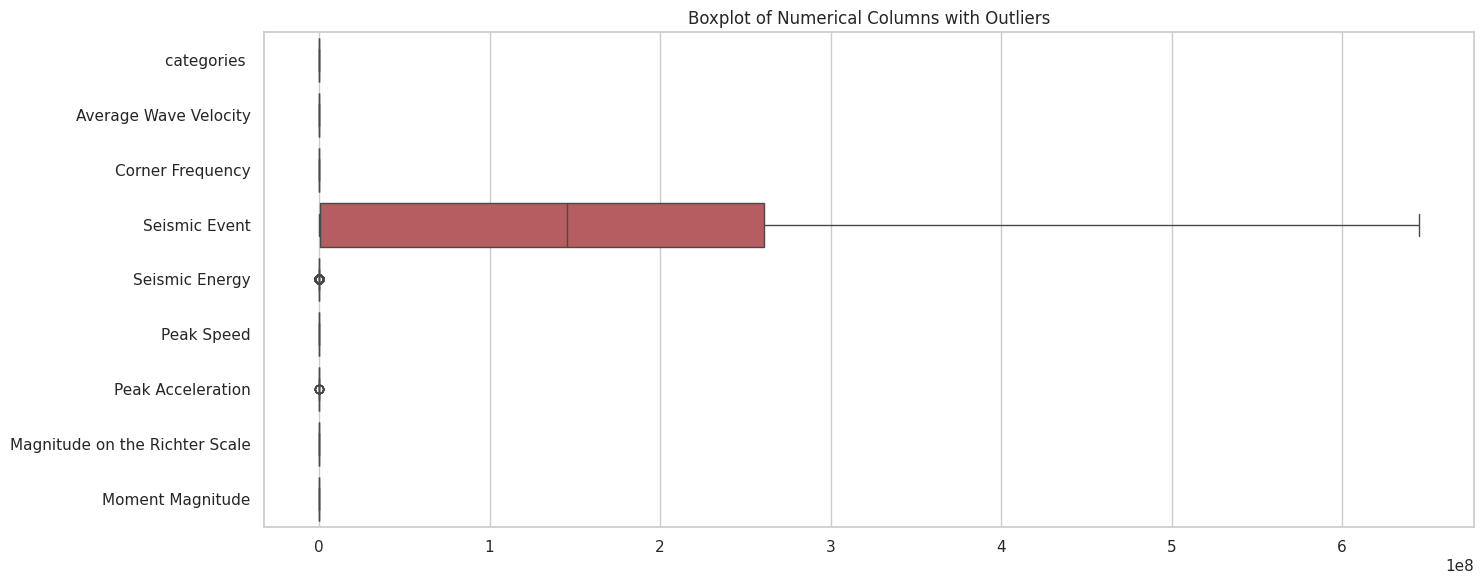

In [553]:

plt.figure(figsize=(15, 6))
sns.boxplot(data=df_witout_outliers.select_dtypes(include='number'),orient='h')
plt.title("Boxplot of Numerical Columns with Outliers")
plt.tight_layout()
plt.show()

In [554]:
df_witout_outliers.isnull().sum()>0

categories                        False
Average Wave Velocity             False
Corner Frequency                  False
Seismic Event                     False
Seismic Energy                    False
Peak Speed                        False
Peak Acceleration                 False
Magnitude on the Richter Scale    False
Moment Magnitude                  False
dtype: bool

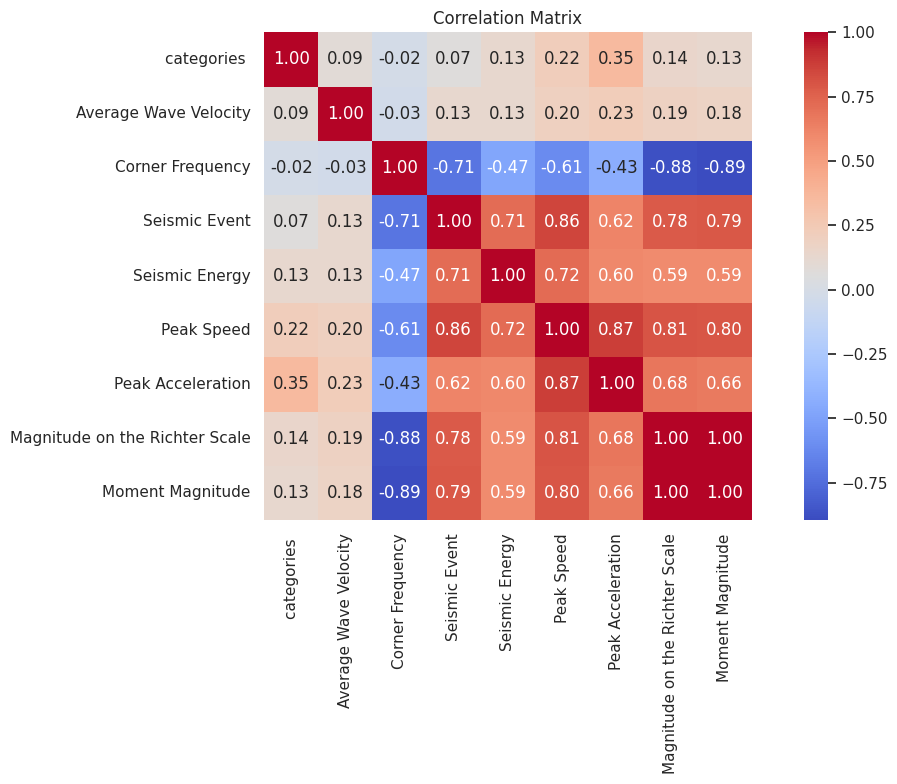

In [555]:
corr_matrix = df_witout_outliers.corr(numeric_only=True)  # Only numerical columns
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar=True)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

High Positive Correlation (≥ 0.8):

Seismic Event & Seismic Energy: 0.84

Peak Speed & Peak Acceleration: 0.91

Magnitude on the Richter Scale & Moment Magnitude: 1.00 → almost perfect collinearity

Seismic Event & Peak Speed: 0.83

Seismic Event & Seismic Energy: 0.84

Peak Speed & Magnitude on the Richter Scale: 0.69

Peak Speed & Moment Magnitude: 0.68

Strong Negative Correlation:

Corner Frequency & Magnitude on the Richter Scale: -0.73

Corner Frequency & Moment Magnitude: -0.75

Corner Frequency & Peak Speed: -0.43

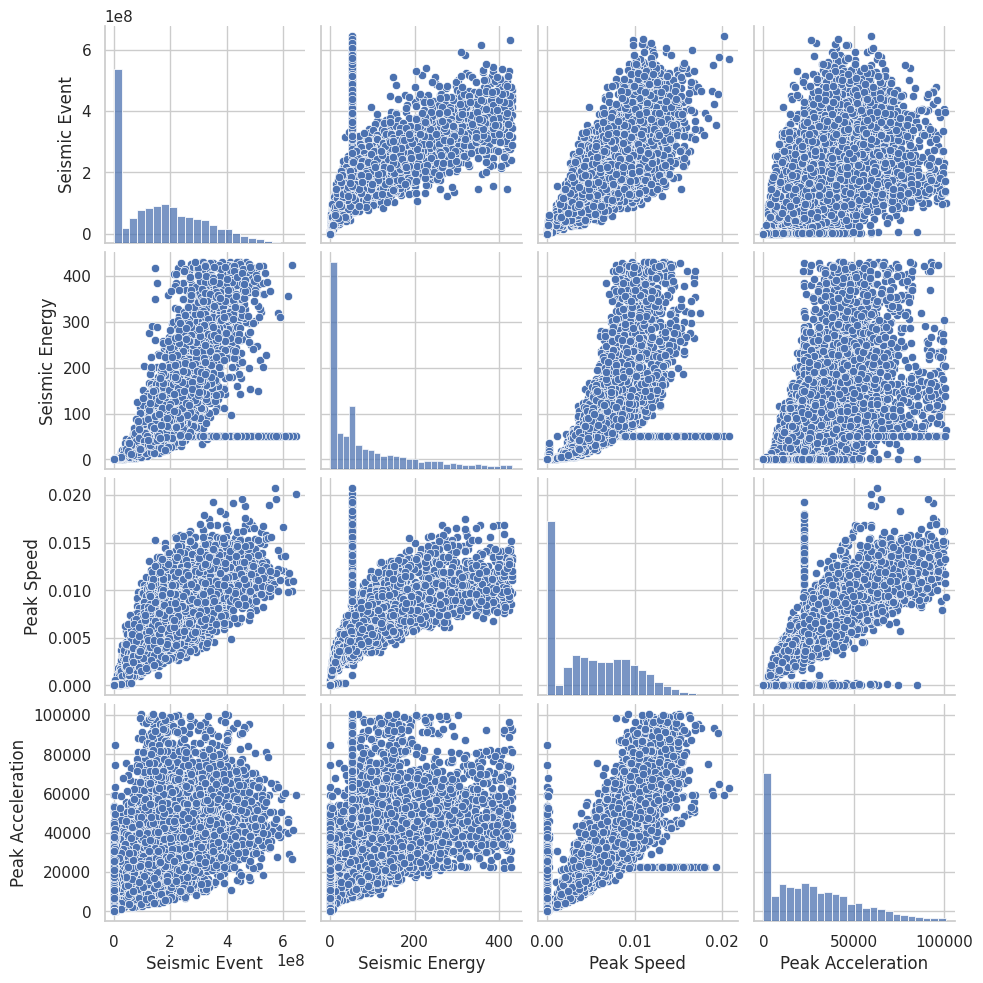

In [556]:
sns.pairplot(df_witout_outliers[['Seismic Event', 'Seismic Energy', 'Peak Speed', 'Peak Acceleration']])


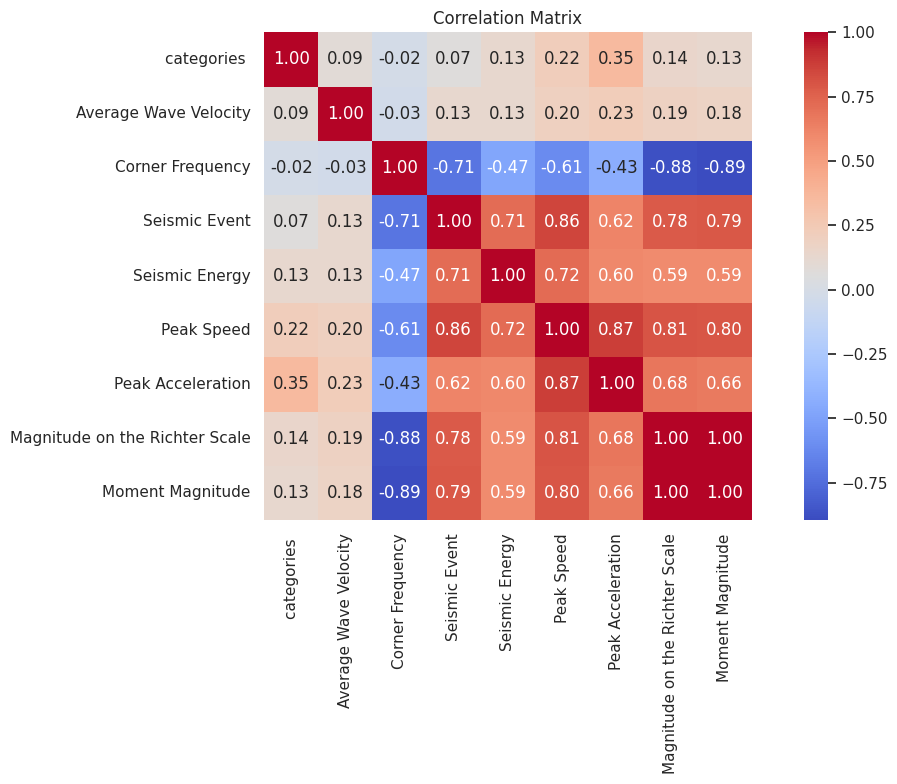

In [557]:
corr_matrix = df_witout_outliers.corr(numeric_only=True)  # Only numerical columns
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar=True)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [558]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
X = add_constant(df_witout_outliers)
vif = pd.DataFrame()
vif["features"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)

                         features           VIF
0                           const   1220.668204
1                     categories       1.198862
2           Average Wave Velocity      1.156368
3                Corner Frequency     54.823990
4                   Seismic Event      8.513803
5                  Seismic Energy      2.276183
6                      Peak Speed     15.630541
7               Peak Acceleration      6.561936
8  Magnitude on the Richter Scale   9741.678542
9                Moment Magnitude  10995.619559


#### Drop features

In [559]:
df_witout_outliers = df_witout_outliers.drop(columns=['Peak Speed','Seismic Event','Moment Magnitude'])  # or 'Peak Acceleration'

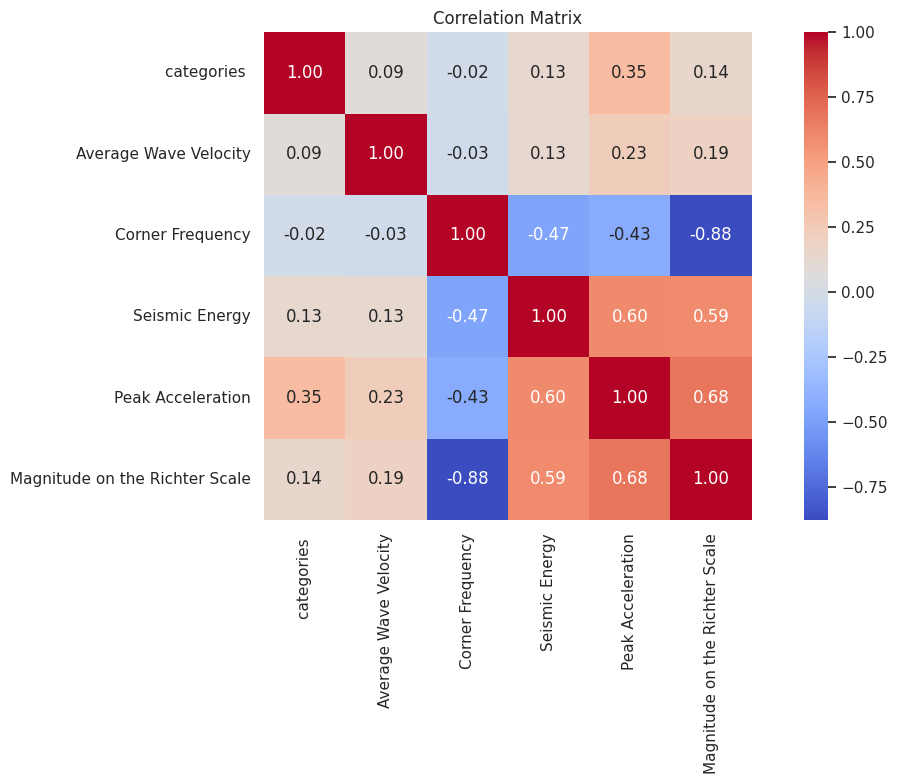

In [560]:
corr_matrix = df_witout_outliers.corr(numeric_only=True)  # Only numerical columns
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar=True)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [561]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
X = add_constant(df_witout_outliers)
vif = pd.DataFrame()
vif["features"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)

                         features        VIF
0                           const  39.291949
1                     categories    1.176551
2           Average Wave Velocity   1.123664
3                Corner Frequency   5.971678
4                  Seismic Energy   1.744320
5               Peak Acceleration   2.877244
6  Magnitude on the Richter Scale   8.974527


### train_val_Test split

In [562]:
# Now split features and target
y = df_witout_outliers["categories "]
X = df_witout_outliers.drop(columns=["categories "])


In [606]:
# Split first
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Scale based on training set only
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns = X.columns)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns = X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns = X.columns)

results = []

### Random Forrest __ Grid Search

#### TrainModel

In [607]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define your model
model = RandomForestClassifier()

# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5)

# Fit GridSearchCV on the validation set

grid_search.fit(X_train_scaled, y_train)

# Get the best parameters
print("Best Parameters:", grid_search.best_params_)

# Train the model with the best hyperparameters on the training set
best_model = grid_search.best_estimator_
best_model.fit(X_train_scaled, y_train)

from sklearn.metrics import accuracy_score, classification_report

# Make predictions on the test set
y_pred = best_model.predict(X_test_scaled)
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

# ✅ Compute metrics
auc = roc_auc_score(y_test, y_proba)
acc = accuracy_score(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_proba)

# Evaluate the model performance
print("Accuracy on Test Set:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Store everything

results.append({
    "Model": "Random_Forest",
    "AUC": auc,
    "Accuracy": acc,
    "FPR": fpr,
    "TPR": tpr,
    "Pred_Proba": y_proba,
    "Pred_Label": y_pred,
    "True_Label": y_test,
    "params":random_search.best_params_
})

summary_df = pd.DataFrame([{
    "Model": r["Model"],
    "AUC": r["AUC"],
    "Accuracy": r["Accuracy"]
} for r in results])

print(summary_df.sort_values(by="AUC", ascending=False))

# Save the model
from joblib import dump
dump(best_model, 'rf.joblib')

Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Accuracy on Test Set: 0.7331002331002331
Classification Report:
               precision    recall  f1-score   support

         0.0       0.76      0.82      0.79       519
         1.0       0.68      0.60      0.64       339

    accuracy                           0.73       858
   macro avg       0.72      0.71      0.71       858
weighted avg       0.73      0.73      0.73       858

           Model      AUC  Accuracy
0  Random_Forest  0.81799    0.7331


['rf.joblib']

#### random forremst Load the model 

In [565]:
from joblib import load
rf = load('rf.joblib')
# Step 5: Evaluate
y_pred = rf.predict(X_test_scaled)
y_proba = rf.predict_proba(X_test_scaled)[:, 1]

# ✅ Compute metrics
auc = roc_auc_score(y_test, y_proba)
acc = accuracy_score(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_proba)

# ✅ Store everything in a dictionary

results.append({
    "Model": "RandomForest",
    "AUC": auc,
    "Accuracy": acc,
    "FPR": fpr,
    "TPR": tpr,
    "Pred_Proba": y_proba,
    "Pred_Label": y_pred,
    "True_Label": y_test,
    "params": xgboost.get_params() 
})


print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba))
print("Classification Report:\n", classification_report(y_test, y_pred))
summary_df = pd.DataFrame([{
    "Model": r["Model"],
    "AUC": r["AUC"],
    "Accuracy": r["Accuracy"]
} for r in results])




Accuracy: 0.7342657342657343
AUC: 0.8095497922599053
Classification Report:
               precision    recall  f1-score   support

         0.0       0.78      0.78      0.78       519
         1.0       0.66      0.66      0.66       339

    accuracy                           0.73       858
   macro avg       0.72      0.72      0.72       858
weighted avg       0.73      0.73      0.73       858



### RandomForest - PCA 

In [566]:
from sklearn.decomposition import PCA

In [595]:
# Keep 4 principal components and fit PCA on training data
pca = PCA(n_components=4)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)  # use transform, not fit_transform


In [596]:
# Step 1: PCA on scaled data
pca = PCA(n_components=4)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Step 2: Define model and hyperparameter grid
rf = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

# Step 3: Grid search
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                           scoring='roc_auc', cv=3, n_jobs=-1, verbose=1)
grid_search.fit(X_train_pca, y_train)

# Step 4: Best model
best_model_pca_rf = grid_search.best_estimator_

# Step 5: Predictions
y_pred = best_model_pca_rf.predict(X_test_pca)
y_proba = best_model_pca_rf.predict_proba(X_test_pca)[:, 1]

# Step 6: Evaluation
auc = roc_auc_score(y_test, y_proba)
acc = accuracy_score(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_proba)

# Step 7: Store results
 # only if not defined earlier
results.append({
    "Model": "Random_Forest_pca",
    "AUC": auc,
    "Accuracy": acc,
    "FPR": fpr,
    "TPR": tpr,
    "Pred_Proba": y_proba,
    "Pred_Label": y_pred,
    "True_Label": y_test,
    "params": best_model.get_params()
})

# Step 8: Print summary
print("Best Parameters:", grid_search.best_params_)
print("Accuracy on Test Set:", acc)
print("Classification Report:\n", classification_report(y_test, y_pred))

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best Parameters: {'bootstrap': True, 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Accuracy on Test Set: 0.7121212121212122
Classification Report:
               precision    recall  f1-score   support

         0.0       0.74      0.82      0.77       519
         1.0       0.66      0.55      0.60       339

    accuracy                           0.71       858
   macro avg       0.70      0.68      0.69       858
weighted avg       0.71      0.71      0.71       858



In [597]:
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", sum(pca.explained_variance_ratio_))


Explained variance ratio: [0.57884407 0.20287241 0.12595456 0.07916202]
Total variance explained: 0.9868330675551291


In [598]:
#results

summary_df = pd.DataFrame([{
    "Model": r["Model"],
    "AUC": r["AUC"],
    "Accuracy": r["Accuracy"]
} for r in results])

print(summary_df.sort_values(by="AUC", ascending=False))


### SVM 

In [599]:
# Step 3: Define parameter grid
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

# Step 4: Train SVM with probability estimates for ROC AUC
svm = SVC(kernel='poly', C=1.0, probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)

# Step 5: Evaluate
y_pred = svm.predict(X_test_scaled)
y_proba = svm.predict_proba(X_test_scaled)[:, 1]

# ✅ Compute metrics
auc = roc_auc_score(y_test, y_proba)
acc = accuracy_score(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_proba)

# ✅ Store everything in a dictionary

results.append({
    "Model": "SVM",
    "AUC": auc,
    "Accuracy": acc,
    "FPR": fpr,
    "TPR": tpr,
    "Pred_Proba": y_proba,
    "Pred_Label": y_pred,
    "True_Label": y_test,
    "params": {
        "kernel": "rbf",
        "C": 1.0,
        "probability": True,
        "random_state": 42
    }
})


print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.703962703962704
AUC: 0.7656771304016687
Classification Report:
               precision    recall  f1-score   support

         0.0       0.71      0.88      0.78       519
         1.0       0.70      0.44      0.54       339

    accuracy                           0.70       858
   macro avg       0.70      0.66      0.66       858
weighted avg       0.70      0.70      0.69       858



In [602]:
results

[{'Model': 'Random_Forrest',
  'AUC': <function sklearn.metrics._ranking.auc(x, y)>,
  'Accuracy': 0.7051282051282052,
  'FPR': array([0.        , 0.        , 0.        , 0.00192678, 0.00192678,
         0.00385356, 0.00385356, 0.00963391, 0.00963391, 0.01348748,
         0.01348748, 0.01734104, 0.01734104, 0.01926782, 0.01926782,
         0.02312139, 0.02312139, 0.02504817, 0.02504817, 0.02890173,
         0.02890173, 0.03082852, 0.03082852, 0.0327553 , 0.0327553 ,
         0.03468208, 0.03468208, 0.03660886, 0.03660886, 0.04046243,
         0.04046243, 0.04238921, 0.04238921, 0.04431599, 0.04431599,
         0.04624277, 0.04624277, 0.05587669, 0.05587669, 0.05780347,
         0.05780347, 0.05973025, 0.05973025, 0.06165703, 0.06165703,
         0.06743738, 0.06743738, 0.07129094, 0.07129094, 0.07321773,
         0.07321773, 0.07514451, 0.07514451, 0.07707129, 0.07707129,
         0.08092486, 0.08092486, 0.08285164, 0.08285164, 0.0867052 ,
         0.0867052 , 0.08863198, 0.08863198, 0

In [600]:
summary_df = pd.DataFrame([{
    "Model": r["Model"],
    "AUC": r["AUC"],
    "Accuracy": r["Accuracy"]
} for r in results])

print(summary_df.sort_values(by="AUC", ascending=False))


TypeError: '>' not supported between instances of 'float' and 'function'

In [601]:
# Check for non-numeric AUC or Accuracy
for r in results:
    if not isinstance(r["AUC"], (int, float)) or not isinstance(r["Accuracy"], (int, float)):
        print(f"Invalid entry found: {r}")


Invalid entry found: {'Model': 'Random_Forrest', 'AUC': <function auc at 0x7c3b36dc0820>, 'Accuracy': 0.7051282051282052, 'FPR': array([0.        , 0.        , 0.        , 0.00192678, 0.00192678,
       0.00385356, 0.00385356, 0.00963391, 0.00963391, 0.01348748,
       0.01348748, 0.01734104, 0.01734104, 0.01926782, 0.01926782,
       0.02312139, 0.02312139, 0.02504817, 0.02504817, 0.02890173,
       0.02890173, 0.03082852, 0.03082852, 0.0327553 , 0.0327553 ,
       0.03468208, 0.03468208, 0.03660886, 0.03660886, 0.04046243,
       0.04046243, 0.04238921, 0.04238921, 0.04431599, 0.04431599,
       0.04624277, 0.04624277, 0.05587669, 0.05587669, 0.05780347,
       0.05780347, 0.05973025, 0.05973025, 0.06165703, 0.06165703,
       0.06743738, 0.06743738, 0.07129094, 0.07129094, 0.07321773,
       0.07321773, 0.07514451, 0.07514451, 0.07707129, 0.07707129,
       0.08092486, 0.08092486, 0.08285164, 0.08285164, 0.0867052 ,
       0.0867052 , 0.08863198, 0.08863198, 0.09055877, 0.09055877,


### XGBOOST 

##### TRained Model

##### XGBoost with loaded model

In [608]:

from joblib import load
xgboost = load('xgboost.joblib')
# Step 5: Evaluate
y_pred = xgboost.predict(X_test_scaled)
y_proba = xgboost.predict_proba(X_test_scaled)[:, 1]

# ✅ Compute metrics
auc = roc_auc_score(y_test, y_proba)
acc = accuracy_score(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_proba)

# ✅ Store everything in a dictionary

results.append({
    "Model": "XGBoost",
    "AUC": auc,
    "Accuracy": acc,
    "FPR": fpr,
    "TPR": tpr,
    "Pred_Proba": y_proba,
    "Pred_Label": y_pred,
    "True_Label": y_test,
    "params": xgboost.get_params() 
})


print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba))
print("Classification Report:\n", classification_report(y_test, y_pred))
summary_df = pd.DataFrame([{
    "Model": r["Model"],
    "AUC": r["AUC"],
    "Accuracy": r["Accuracy"]
} for r in results])

#print(summary_df.sort_values(by="AUC", ascending=False))


Accuracy: 0.7342657342657343
AUC: 0.8193542153335495
Classification Report:
               precision    recall  f1-score   support

         0.0       0.76      0.82      0.79       519
         1.0       0.69      0.60      0.64       339

    accuracy                           0.73       858
   macro avg       0.72      0.71      0.71       858
weighted avg       0.73      0.73      0.73       858



###  LightGBM (CPU unless GPU enabled in build)


##### TRAINED MODEL 

In [ ]:
# Save the model
from joblib import dump
dump(lgb_best, 'lightGBM.joblib')

##### Loaded Model 

In [609]:

from joblib import load
lightGBM = load('lightGBM.joblib')
# Step 5: Evaluate
y_pred = xgboost.predict(X_test_scaled)
y_proba = xgboost.predict_proba(X_test_scaled)[:, 1]

# ✅ Compute metrics
auc = roc_auc_score(y_test, y_proba)
acc = accuracy_score(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_proba)

# ✅ Store everything in a dictionary

results.append({
    "Model": "lightGBM",
    "AUC": auc,
    "Accuracy": acc,
    "FPR": fpr,
    "TPR": tpr,
    "Pred_Proba": y_proba,
    "Pred_Label": y_pred,
    "True_Label": y_test,
    "params": lightGBM.get_params() 
})


print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba))
print("Classification Report:\n", classification_report(y_test, y_pred))
summary_df = pd.DataFrame([{
    "Model": r["Model"],
    "AUC": r["AUC"],
    "Accuracy": r["Accuracy"]
} for r in results])




Accuracy: 0.7342657342657343
AUC: 0.8193542153335495
Classification Report:
               precision    recall  f1-score   support

         0.0       0.76      0.82      0.79       519
         1.0       0.69      0.60      0.64       339

    accuracy                           0.73       858
   macro avg       0.72      0.71      0.71       858
weighted avg       0.73      0.73      0.73       858



### AdaBoost

In [610]:
# Base estimator: simple decision tree
# Define base estimator
base_estimator = DecisionTreeClassifier()

# Define AdaBoost classifier using the 'estimator' argument
ada_model = AdaBoostClassifier(estimator=base_estimator, random_state=42)

# Define the hyperparameter grid using 'estimator__' prefix
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1],
    'estimator__max_depth': [1, 2, 3],
    'estimator__min_samples_split': [2, 5, 10],
}

# Grid search
grid_search = GridSearchCV(ada_model, param_grid, scoring='roc_auc', cv=3)
grid_search.fit(X_train_scaled, y_train)

# Results
print("Best Parameters:", grid_search.best_params_)
print("Best AUC Score:", grid_search.best_score_)


Best Parameters: {'estimator__max_depth': 2, 'estimator__min_samples_split': 2, 'learning_rate': 1, 'n_estimators': 200}
Best AUC Score: 0.8107443809498562


In [611]:
ada_best = grid_search.best_estimator_

In [612]:
from sklearn.metrics import accuracy_score, classification_report,roc_curve,roc_auc_score


In [613]:
# Step 5: Evaluate
y_pred = ada_best.predict(X_test_scaled)
y_proba = ada_best.predict_proba(X_test_scaled)[:, 1]

# ✅ Compute metrics
auc = roc_auc_score(y_test, y_proba)
acc = accuracy_score(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_proba)

# ✅ Store everything in a dictionary

results.append({
    "Model": "AdaBoost",
    "AUC": auc,
    "Accuracy": acc,
    "FPR": fpr,
    "TPR": tpr,
    "Pred_Proba": y_proba,
    "Pred_Label": y_pred,
    "True_Label": y_test,
    "params": ada_best.get_params() 
})


print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7377622377622378
AUC: 0.7957184510716659
Classification Report:
               precision    recall  f1-score   support

         0.0       0.76      0.82      0.79       519
         1.0       0.69      0.61      0.65       339

    accuracy                           0.74       858
   macro avg       0.73      0.72      0.72       858
weighted avg       0.73      0.74      0.73       858



In [614]:
# Save the model
from joblib import dump
dump(ada_best, 'AdaBoost.joblib')

['AdaBoost.joblib']

### CatBoost

In [615]:
from catboost import CatBoostClassifier


# Define CatBoost model
cat_model = CatBoostClassifier(verbose=0, random_state=42)

# Define hyperparameter grid
param_grid = {
    'iterations': [100, 300],
    'learning_rate': [0.01, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5]
}

# GridSearchCV
cat_grid = GridSearchCV(estimator=cat_model, param_grid=param_grid, 
                        scoring='roc_auc', cv=3, n_jobs=-1)
cat_grid.fit(X_train_scaled, y_train)

# Results
print("Best Parameters:", cat_grid.best_params_)
print("Best AUC Score:", cat_grid.best_score_)
cat_best = grid_search.best_estimator_

Best Parameters: {'depth': 8, 'iterations': 100, 'l2_leaf_reg': 1, 'learning_rate': 0.1}
Best AUC Score: 0.8295516231198565


In [616]:
# Step 5: Evaluate
y_pred = cat_best.predict(X_test_scaled)
y_proba = cat_best.predict_proba(X_test_scaled)[:, 1]

# ✅ Compute metrics
auc = roc_auc_score(y_test, y_proba)
acc = accuracy_score(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_proba)

# ✅ Store everything in a dictionary

results.append({
    "Model": "CatBoost",
    "AUC": auc,
    "Accuracy": acc,
    "FPR": fpr,
    "TPR": tpr,
    "Pred_Proba": y_proba,
    "Pred_Label": y_pred,
    "True_Label": y_test,
    "params": cat_best.get_params() 
})


print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7377622377622378
AUC: 0.7957184510716659
Classification Report:
               precision    recall  f1-score   support

         0.0       0.76      0.82      0.79       519
         1.0       0.69      0.61      0.65       339

    accuracy                           0.74       858
   macro avg       0.73      0.72      0.72       858
weighted avg       0.73      0.74      0.73       858



In [617]:
# Save the model
from joblib import dump
dump(cat_best, 'CatBoost.joblib')

['CatBoost.joblib']

### VOTER

In [618]:
xgb = xgboost
rf = best_model_rf
rf_pca= best_model_pca_rf
ada = ada_best


In [619]:
# Voting Classifier
from sklearn.ensemble import VotingClassifier

voter = VotingClassifier(
    estimators=[
        ('xgb', xgb),
        ('rf', rf),
        ('rf_pca', rf_pca),
        ('ada', ada)
    ],
    voting='soft'  # use 'hard' for majority vote, 'soft' for averaged predicted probabilities
)
voter.fit(X_train_scaled, y_train)

VotingClassifier(estimators=[('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=1.0, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='logloss',
                                            feature_types=None,
                                            feature_weights=None, gamma=0,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constr...
                                            num_parallel_tree=None, ...)),
                             ('rf',
                              RandomForestClassifier(max_depth=10,
                                                     min_samples_split=5)),
                             ('rf_pca',
                              RandomForestClassifier(max_depth=10,
                                                     min_samples_leaf=2,
                                                     min_samples_split=5,
                                                     n_estimators=200,
                                                     random_state=42)),
                             ('ada',
                              AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2),
                                                 learning_rate=1,
                                                 n_estimators=200,
                                                 random_state=42))],
                 voting='soft')

In [620]:
# Step 5: Evaluate
y_pred = voter.predict(X_test_scaled)
y_proba = voter.predict_proba(X_test_scaled)[:, 1]

# ✅ Compute metrics
auc = roc_auc_score(y_test, y_proba)
acc = accuracy_score(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_proba)

# ✅ Store everything in a dictionary

results.append({
    "Model": "Voter",
    "AUC": auc,
    "Accuracy": acc,
    "FPR": fpr,
    "TPR": tpr,
    "Pred_Proba": y_proba,
    "Pred_Label": y_pred,
    "True_Label": y_test,
    "params": voter.get_params() 
})


print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7377622377622378
AUC: 0.8211502719661705
Classification Report:
               precision    recall  f1-score   support

         0.0       0.76      0.83      0.79       519
         1.0       0.70      0.60      0.64       339

    accuracy                           0.74       858
   macro avg       0.73      0.71      0.72       858
weighted avg       0.73      0.74      0.73       858



### Neural Network 

Epoch [1/40], Train Loss: 3.4089, Test Loss: 2.7557, Train Accuracy: 0.4308, Test Accuracy: 0.6562
Epoch [2/40], Train Loss: 1.9635, Test Loss: 1.7522, Train Accuracy: 0.7030, Test Accuracy: 0.6783
Epoch [3/40], Train Loss: 1.2148, Test Loss: 1.1590, Train Accuracy: 0.7168, Test Accuracy: 0.7040
Epoch [4/40], Train Loss: 0.9328, Test Loss: 1.0162, Train Accuracy: 0.7113, Test Accuracy: 0.6958
Epoch [5/40], Train Loss: 0.8208, Test Loss: 0.8763, Train Accuracy: 0.7150, Test Accuracy: 0.7063
Epoch [6/40], Train Loss: 0.7427, Test Loss: 0.8058, Train Accuracy: 0.7173, Test Accuracy: 0.7028
Epoch [7/40], Train Loss: 0.7095, Test Loss: 0.7715, Train Accuracy: 0.7230, Test Accuracy: 0.7040
Epoch [8/40], Train Loss: 0.6878, Test Loss: 0.7489, Train Accuracy: 0.7253, Test Accuracy: 0.7005
Epoch [9/40], Train Loss: 0.6727, Test Loss: 0.7250, Train Accuracy: 0.7200, Test Accuracy: 0.7051
Epoch [10/40], Train Loss: 0.6584, Test Loss: 0.7205, Train Accuracy: 0.7203, Test Accuracy: 0.7063
Epoch [11

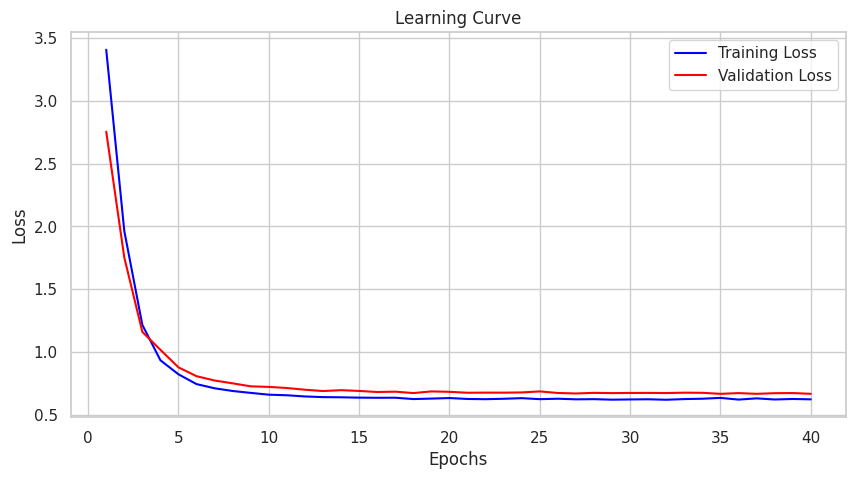

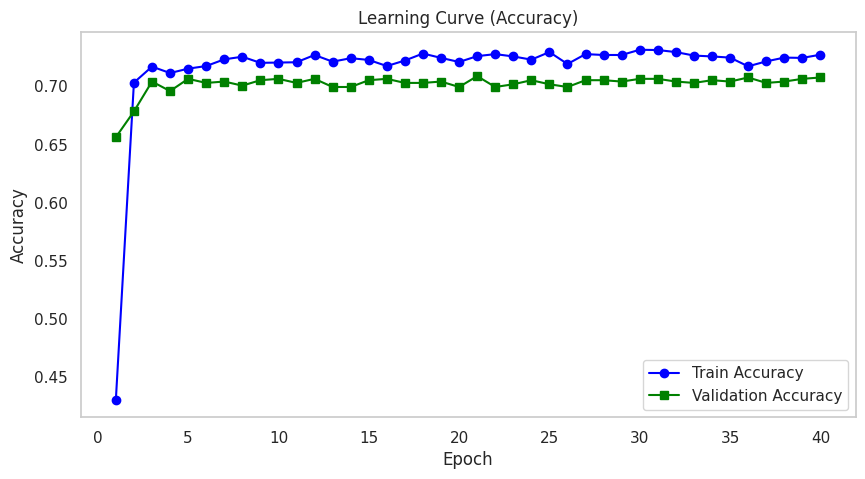

In [621]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

# Convert DataFrames to NumPy arrays
X_train_np = X_train_scaled.to_numpy()
X_test_np = X_test_scaled.to_numpy()
y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

# Normalize features
#scaler = StandardScaler()
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_np = scaler.fit_transform(X_train_np)
X_test_np = scaler.transform(X_test_np)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_np, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_np, dtype=torch.long)  # Use long for classification
X_test_tensor = torch.tensor(X_test_np, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_np, dtype=torch.long)

# Create Dataloaders
batch_size = 25
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


class RockburstNet(nn.Module):
    def __init__(self, input_dim):
        super(RockburstNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.relu = nn.ReLU()
        self.fc3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)
        self.fc4 = nn.Linear(64, 2)  # Binary classification
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.relu(self.bn2(self.fc2(x)))
        x = self.fc3(x)
        return x

model = RockburstNet(input_dim=X_train.shape[1])


#optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.8, weight_decay=1e-6)
# Using RMSprop optimizer
#optimizer = optim.RMSprop(model.parameters(), lr=0.001, weight_decay=1e-4, momentum=0.9)
optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)


# Lists to store loss and accuracy
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

# Loss function
criterion = nn.CrossEntropyLoss()

# Training loop
num_epochs = 40
for epoch in range(num_epochs):
    model.train()  # Set model to training mode
    total_train_loss = 0
    correct_train = 0
    total_train = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

        # Compute training accuracy
        _, predicted = torch.max(outputs, 1)
        total_train += y_batch.size(0)
        correct_train += (predicted == y_batch).sum().item()

    # Store average training loss and accuracy
    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    train_acc = correct_train / total_train
    train_accuracies.append(train_acc)

    # Evaluate model on test (validation) data
    model.eval()  # Set model to evaluation mode
    total_test_loss = 0
    correct_test = 0
    total_test = 0

    with torch.no_grad():  # No gradient computation
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)  # Compute test loss
            total_test_loss += loss.item()

            # Compute testing accuracy
            _, predicted = torch.max(outputs, 1)
            total_test += y_batch.size(0)
            correct_test += (predicted == y_batch).sum().item()

    # Store average test loss and accuracy
    avg_test_loss = total_test_loss / len(test_loader)
    test_losses.append(avg_test_loss)
    
    test_acc = correct_test / total_test
    test_accuracies.append(test_acc)

    # Print training progress
    print(f"Epoch [{epoch+1}/{num_epochs}], "
          f"Train Loss: {avg_train_loss:.4f}, "
          f"Test Loss: {avg_test_loss:.4f}, "
          f"Train Accuracy: {train_acc:.4f}, "
          f"Test Accuracy: {test_acc:.4f}")

    # Step the learning rate scheduler
    scheduler.step()

avg_test_accuracy = np.mean(test_accuracies)
print(f"Average Test Accuracy: {avg_test_accuracy:.4f}")


# Plot Learning Curve
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), train_losses, label="Training Loss", color='blue')
plt.plot(range(1, num_epochs + 1), test_losses, label="Validation Loss", color='red')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Learning Curve")
plt.legend()
plt.show()

# Plot Accuracy Learning Curve
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), train_accuracies, label="Train Accuracy", marker='o', color='blue')
plt.plot(range(1, num_epochs + 1), test_accuracies, label="Validation Accuracy", marker='s', color='green')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Learning Curve (Accuracy)")
plt.legend()
plt.grid()
plt.show()

In [622]:
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve
import numpy as np

# Put model in evaluation mode
model.eval()

# Collect predictions and true labels
all_probs = []
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        probs = torch.softmax(outputs, dim=1)  # Get probabilities
        _, preds = torch.max(probs, 1)

        all_probs.extend(probs[:, 1].cpu().numpy())  # Assuming class 1 is the positive class
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

# Convert to NumPy arrays
y_proba = np.array(all_probs)
y_pred = np.array(all_preds)
y_true = np.array(all_labels)

# Compute metrics
auc = roc_auc_score(y_true, y_proba)
acc = accuracy_score(y_true, y_pred)
fpr, tpr, _ = roc_curve(y_true, y_proba)

# Save results

results.append({
    "Model": "RockburstNet",
    "AUC": auc,
    "Accuracy": acc,
    "FPR": fpr,
    "TPR": tpr,
    "Pred_Proba": y_proba,
    "Pred_Label": y_pred,
    "True_Label": y_true,
    "params": model.state_dict()  # or replace with model config if needed
})


### Results

summary_df = pd.DataFrame([{
    "Model": r["Model"],
    "AUC": r["AUC"],
    "Accuracy": r["Accuracy"]
} for r in results])

print(summary_df.sort_values(by="AUC", ascending=False))

#### BARPLOT-ACCURACY

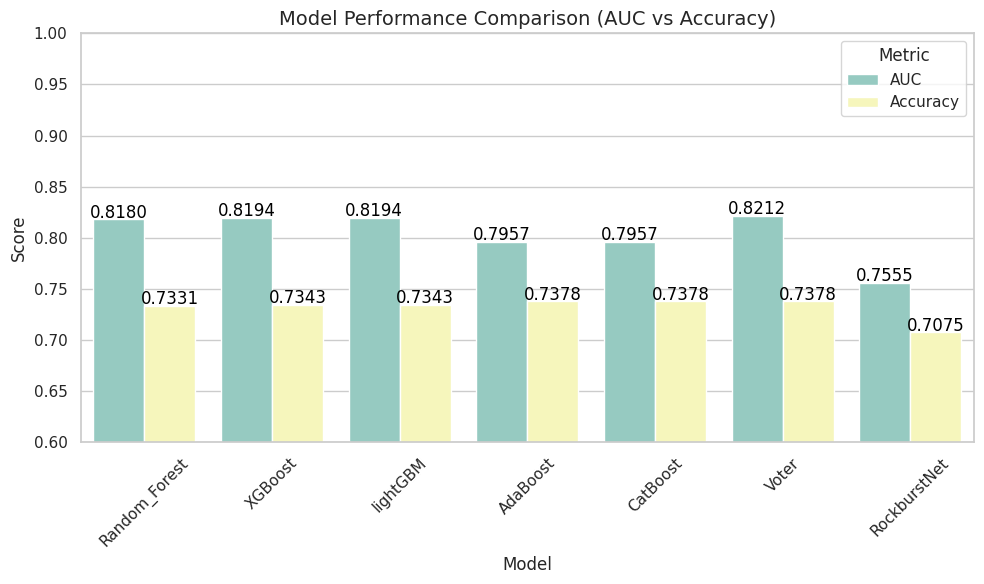

In [623]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Melt the dataframe to long format for seaborn
plot_df = results_df.melt(id_vars='Model', value_vars=['AUC', 'Accuracy'],
                          var_name='Metric', value_name='Score')

# Set seaborn style
sns.set(style="whitegrid")

# Create bar plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=plot_df, x='Model', y='Score', hue='Metric', palette='Set3')

# Annotate the bars with the exact values
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                fontsize=12, color='black', 
                xytext=(0, 5), textcoords='offset points')

# Customize the plot
plt.title('Model Performance Comparison (AUC vs Accuracy)', fontsize=14)
plt.ylabel('Score')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.ylim(0.6, 1.0)  # Optional: Adjust based on your values
plt.legend(title='Metric')
plt.tight_layout()
plt.show()


In [624]:
# Check for non-numeric AUC or Accuracy
for r in results:
    if not isinstance(r["AUC"], (int, float)) or not isinstance(r["Accuracy"], (int, float)):
        print(f"Invalid entry found: {r}")


#### ROC

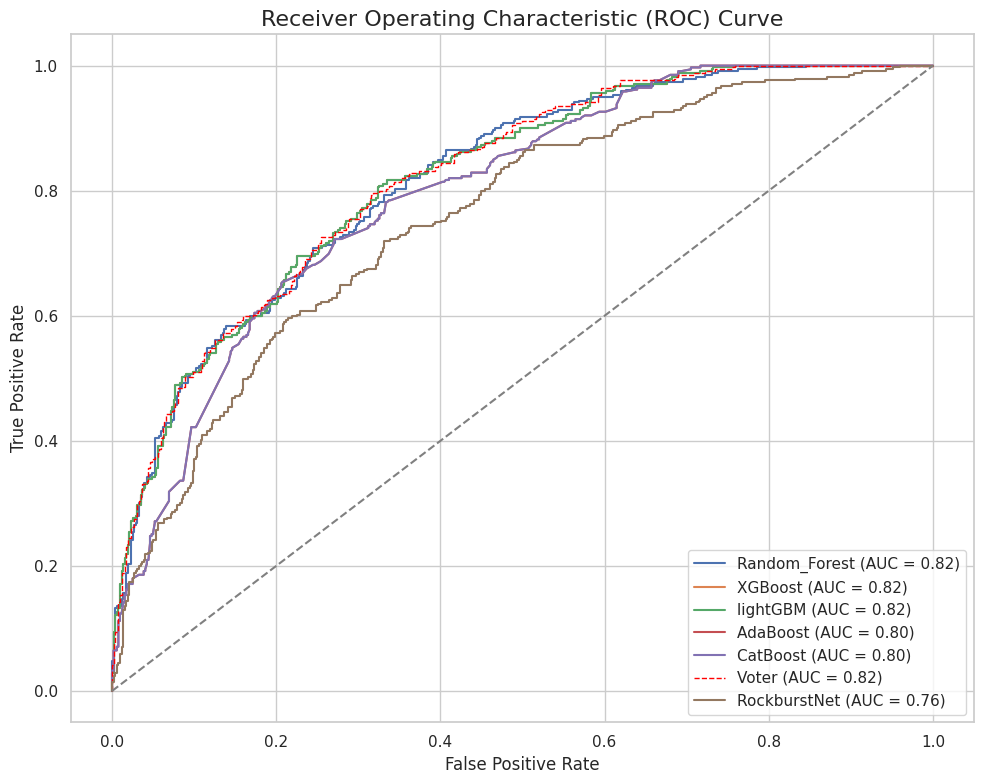

In [625]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set(style="whitegrid")

# Create a figure to hold the ROC curves
plt.figure(figsize=(10, 8))

# Plot the ROC curve for each model
for result in results:
    model_name = result["Model"]
    y_test = result["True_Label"]
    y_proba = result["Pred_Proba"]
    
    # Compute ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    
    # Compute AUC
    auc = roc_auc_score(y_test, y_proba)
    
    # Check if the current model is "Voter"
    if model_name == "Voter":
        # Make Voter's line more visible by setting a unique color, line style, and thickness
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.2f})', color='red', linestyle='--', linewidth=1, marker='', markersize=6)
    else:
        # Plot other models with default style
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.2f})')

# Plot the diagonal line (random classifier)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

# Customize the plot
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=16)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


#### pr-curve

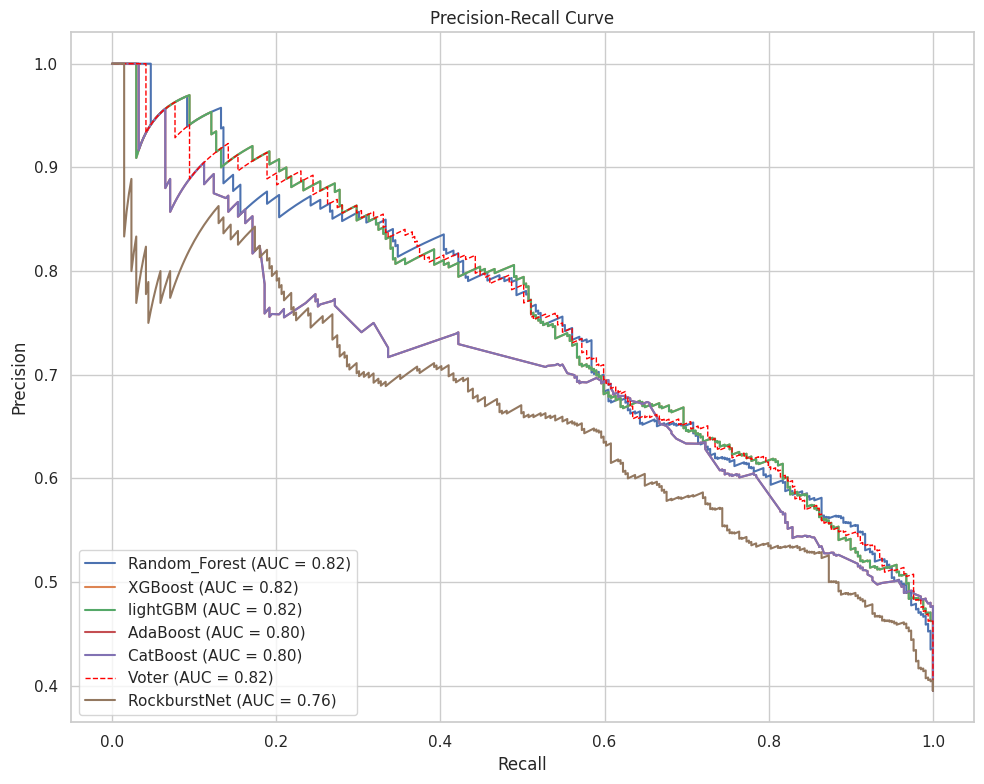

In [626]:
from sklearn.metrics import precision_recall_curve, roc_auc_score
import matplotlib.pyplot as plt

# Plot Precision-Recall curve for each model
plt.figure(figsize=(10, 8))  # Create a larger figure for better visibility

for result in results:
    model_name = result["Model"]
    y_test = result["True_Label"]
    y_proba = result["Pred_Proba"]
    
    # Compute Precision-Recall curve
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    
    # Check if the current model is "Voter"
    if model_name == "Voter":
        # Make Voter's line more visible by setting a unique color, line style, and thickness
        plt.plot(recall, precision, label=f'{model_name} (AUC = {roc_auc_score(y_test, y_proba):.2f})', color='red', linestyle='--', linewidth=1, marker='', markersize=6)
    else:
        # Plot other models with default style
        plt.plot(recall, precision, label=f'{model_name} (AUC = {roc_auc_score(y_test, y_proba):.2f})')

# Customize the plot
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()


#### Feature Importance


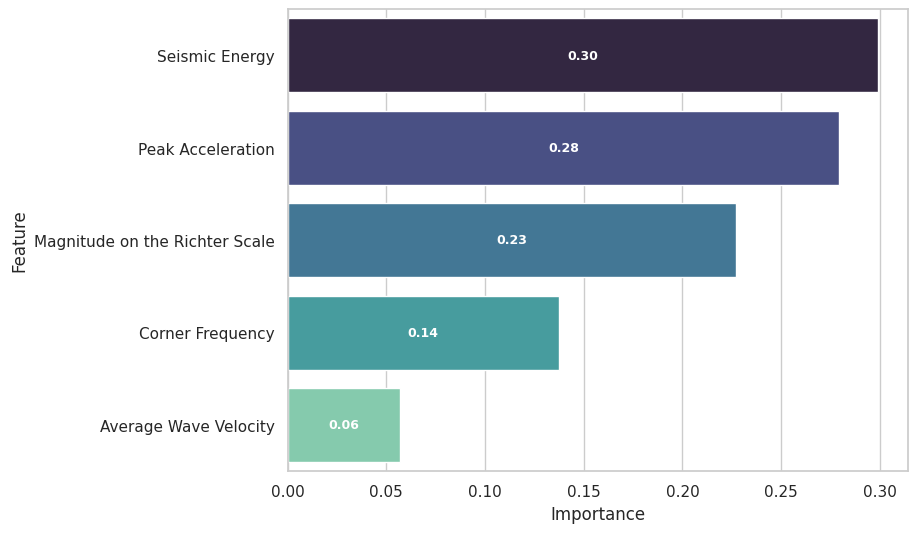

In [627]:
ax = sns.barplot(data=importance_df, y='Feature', x='Importance', palette='mako')
for p in ax.patches:
    width = p.get_width()
    ax.text(
        width * 0.5,
        p.get_y() + p.get_height() / 2,
        f"{width:.2f}",
        ha='center', va='center', fontsize=9, color='white', fontweight='bold'
    )


#### Learning Curve for voter

### misclassified 


### Error Analysis

In [651]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05)
outliers = iso.fit_predict(X_train)

# -1 means outlier
X_train['outlier'] = outliers
print(X_train[X_train['outlier'] == -1])


      Average Wave Velocity  Corner Frequency  Seismic Energy  \
3501            5176.872870        268.307396      137.421089   
3383            6225.855352        293.731520      191.708309   
5292            2901.000013        444.083941        0.001108   
715             5867.170715        327.465962       33.478272   
2278            3000.499984        157.554381      425.182612   
...                     ...               ...             ...   
3411            3001.000012        176.747738      361.401220   
2430            3001.000012        215.971512      420.925347   
5535            2901.000013        266.638440        0.001153   
2141            6499.432703        338.667049        9.254014   
3750            2901.000013        290.530833      125.398725   

      Peak Acceleration  Magnitude on the Richter Scale  outlier  
3501      100150.148908                        0.005138       -1  
3383       88001.585784                        0.117735       -1  
5292       20815.8

In [632]:
from sklearn.metrics import f1_score, precision_recall_curve

y_probs = voter.predict_proba(X_test_scaled)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
best_threshold = thresholds[f1_scores.argmax()]
print(f"Best threshold for F1: {best_threshold:.2f}")


Best threshold for F1: 0.39


In [633]:
y_pred = (y_probs > best_threshold).astype(int)


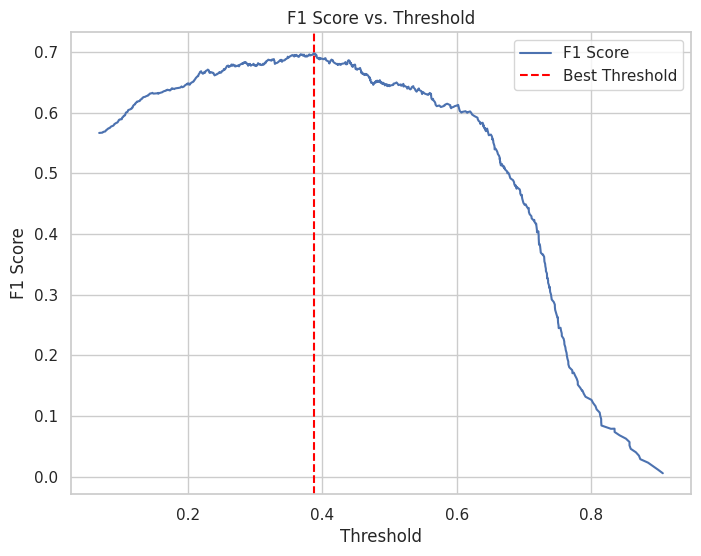

In [634]:
import matplotlib.pyplot as plt

plt.plot(thresholds, f1_scores[:-1], label='F1 Score')
plt.axvline(x=best_threshold, color='red', linestyle='--', label='Best Threshold')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.legend()
plt.title('F1 Score vs. Threshold')
plt.show()


In [635]:
# Use optimized threshold
y_pred_optimized = (y_probs >= 0.36).astype(int)

# New classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_optimized))


              precision    recall  f1-score   support

           0       0.85      0.65      0.73       519
           1       0.60      0.82      0.69       339

    accuracy                           0.71       858
   macro avg       0.72      0.73      0.71       858
weighted avg       0.75      0.71      0.72       858



In [636]:
xgboost

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [637]:
X_test_scaled.columns

Index(['Average Wave Velocity', 'Corner Frequency', 'Seismic Energy',
       'Peak Acceleration', 'Magnitude on the Richter Scale'],
      dtype='object')

In [638]:
X_train_scaled.columns

Index(['Average Wave Velocity', 'Corner Frequency', 'Seismic Energy',
       'Peak Acceleration', 'Magnitude on the Richter Scale'],
      dtype='object')

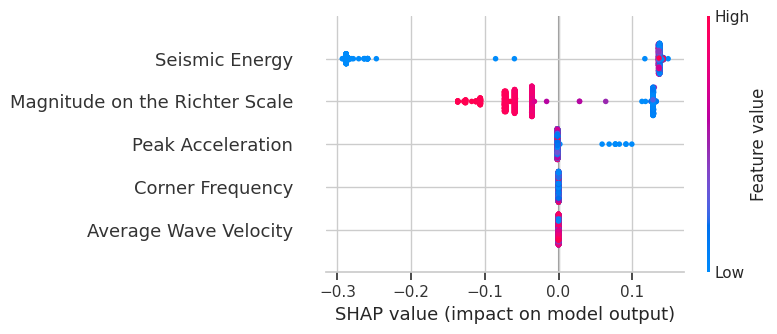

In [639]:
explainer = shap.Explainer(xgboost, X_train)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)


In [643]:
import lime
import lime.lime_tabular
import numpy as np

# Assuming X_train is your training data (numpy array or DataFrame)
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    class_names=['Microseisimic', 'Seisimic'],  # Adjust to your labels
    mode='classification'
)


In [644]:
# Pick a sample from test data
i = 0
exp = explainer.explain_instance(
    data_row=X_test.iloc[i],
    predict_fn=voter.predict_proba
)

# Show explanation in notebook
exp.show_in_notebook(show_table=True)

# Or save it to HTML
exp.save_to_file('lime_explanation.html')


In [645]:
# Pick a sample from test data
i = 5
exp = explainer.explain_instance(
    data_row=X_test.iloc[i],
    predict_fn=voter.predict_proba
)

# Show explanation in notebook
exp.show_in_notebook(show_table=True)

# Or save it to HTML
exp.save_to_file('lime_explanation.html')
